# ColumnTransformer in Sklearn

-----
-----

In [1]:
import numpy as np 
import pandas as pd

In [3]:
df = pd.read_csv(r"D:/ML/DataSet/covid_toy.csv")

In [4]:
df.sample(5)

,age,gender,fever,cough,city,has_covid
66,51,Male,104.0,Mild,Kolkata,No
1,27,Male,100.0,Mild,Delhi,Yes
87,47,Male,101.0,Strong,Bangalore,No
97,20,Female,101.0,Mild,Bangalore,No
21,73,Male,98.0,Mild,Bangalore,Yes


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        100 non-null    int64  
 1   gender     100 non-null    str    
 2   fever      90 non-null     float64
 3   cough      100 non-null    str    
 4   city       100 non-null    str    
 5   has_covid  100 non-null    str    
dtypes: float64(1), int64(1), str(4)
memory usage: 4.8 KB


In [8]:
from sklearn.impute import SimpleImputer        #this is helpfull when we have missing values
from sklearn.preprocessing import OneHotEncoder        #this is helpfull when we have nominal categorical values
from sklearn.preprocessing import OrdinalEncoder        #this is helpfull when we have ordinal categorical values

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['has_covid' ]), df['has_covid'],test_size=0.2)

In [17]:
df['cough'].value_counts()          #this will return us the amount of rows each type have

cough
Mild      62
Strong    38
Name: count, dtype: int64

In [18]:
df['city'].value_counts()     

city
Kolkata      32
Bangalore    30
Delhi        22
Mumbai       16
Name: count, dtype: int64

In [19]:
X_train

,age,gender,fever,cough,city
19,42,Female,NaN,Strong,Bangalore
35,82,Female,102.0,Strong,Bangalore
96,51,Female,101.0,Strong,Kolkata
29,34,Female,NaN,Strong,Mumbai
75,5,Male,102.0,Mild,Kolkata
...,...,...,...,...,...
73,34,Male,98.0,Strong,Kolkata
63,10,Male,100.0,Mild,Bangalore
28,16,Male,104.0,Mild,Kolkata
71,75,Female,104.0,Strong,Delhi


age = integral, gender and city = nominal categorical data , fever = integral with missing data , cough = ordinal categorical data , has_covid = o/p categorical data => apply label encoding

1} AAM ZINDAGI

        ->in this we will see what will we do if we dont know about the column transformer

In [27]:
# adding simple imputer to fever columns
si = SimpleImputer()
X_train_fever = si.fit_transform(X_train[['fever']])

#here we also train on the test data
X_test_fever = si.transform(X_test[['fever']])

X_train_fever.shape


(80, 1)

In [28]:
# Ordinalencoding -> cough
oe = OrdinalEncoder(categories=[['Mild', 'Strong' ]])
X_train_cough = oe.fit_transform(X_train[['cough' ]])

# also the test data
X_test_cough = oe.transform(X_test[['cough' ]])

X_train_cough.shape

(80, 1)

In [29]:
# OneHotEncoding -> gender,city
ohe = OneHotEncoder(drop='first', sparse_output=False)
X_train_gender_city = ohe.fit_transform(X_train[['gender', 'city' ]])

# also the test data
X_test_gender_city = ohe.transform(X_test[['gender', 'city']])

X_train_gender_city.shape

(80, 4)

In [30]:
X_train

,age,gender,fever,cough,city
19,42,Female,NaN,Strong,Bangalore
35,82,Female,102.0,Strong,Bangalore
96,51,Female,101.0,Strong,Kolkata
29,34,Female,NaN,Strong,Mumbai
75,5,Male,102.0,Mild,Kolkata
...,...,...,...,...,...
73,34,Male,98.0,Strong,Kolkata
63,10,Male,100.0,Mild,Bangalore
28,16,Male,104.0,Mild,Kolkata
71,75,Female,104.0,Strong,Delhi


now before we concatenate we will take out the age column

In [31]:
# Extracting Age
X_train_age = X_train.drop(columns=['gender','fever','cough', 'city']).values

# also the test data
X_test_age = X_test.drop(columns=['gender', 'fever', 'cough', 'city']).values

X_train_age. shape

(80, 1)

In [32]:
X_train_transformed = np.concatenate((X_train_age,X_train_fever,X_train_gender_city,X_train_cough),axis=1)
# also the test data
X_test_transformed = np.concatenate((X_test_age,X_test_fever,X_test_gender_city,X_test_cough),axis=1)

X_train_transformed.shape

(80, 7)

## Mentos Zindagi

In [33]:
from sklearn.compose import ColumnTransformer       #learn this code

In [36]:
transformer = ColumnTransformer(transformers=[
    ('tnf1',SimpleImputer(), ['fever']),
    ('tnf2',OrdinalEncoder(categories=[ ['Mild', 'Strong' ]]), ['cough' ]),
    ('tnf3',OneHotEncoder(sparse_output=False, drop='first'), ['gender', 'city'])
], remainder='passthrough')

#this is the code.
#inside the column transformer function we pass a transformer parameter with a list which have tuples and the no. = no. of the
# transformer required and then we have named it and then put the transformer with the required detail and then column on which 
# it is to be acted upon. and then we pass a remainder column which is either drop or passthrough which helps to tell us that 
# the data not used to leave and pass ,or to drop those 

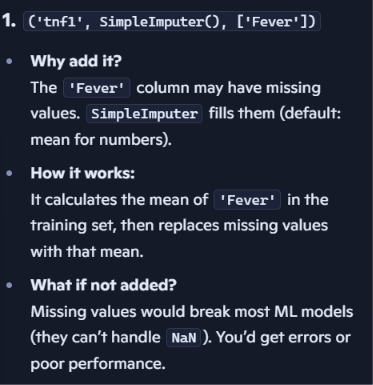
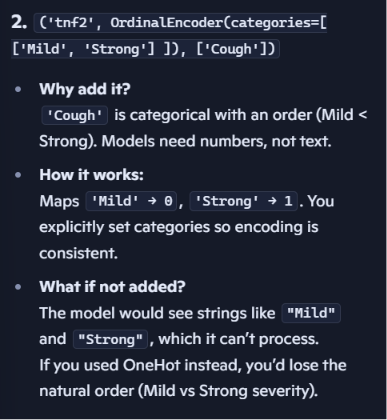
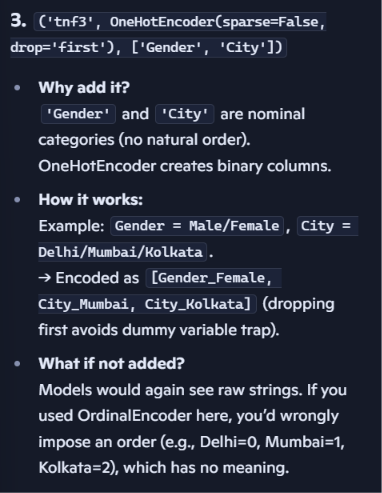
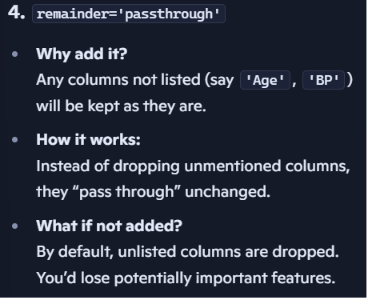
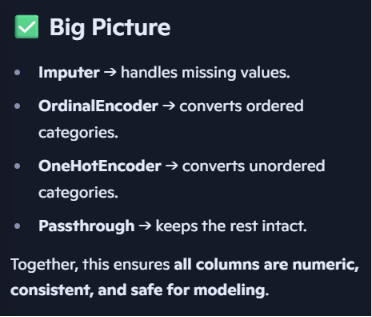

In [37]:
transformer.fit_transform(X_train)

array([[100.73239437,   1.        ,   0.        ,   0.        ,
          0.        ,   0.        ,  42.        ],
       [102.        ,   1.        ,   0.        ,   0.        ,
          0.        ,   0.        ,  82.        ],
       [101.        ,   1.        ,   0.        ,   0.        ,
          1.        ,   0.        ,  51.        ],
       [100.73239437,   1.        ,   0.        ,   0.        ,
          0.        ,   1.        ,  34.        ],
       [102.        ,   0.        ,   1.        ,   0.        ,
          1.        ,   0.        ,   5.        ],
       [ 99.        ,   0.        ,   1.        ,   0.        ,
          0.        ,   0.        ,  72.        ],
       [100.        ,   0.        ,   1.        ,   0.        ,
          1.        ,   0.        ,  55.        ],
       [102.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,  69.        ],
       [104.        ,   1.        ,   0.        ,   1.        ,
          0.    

In [40]:
transformer.transform(X_test)

array([[ 99.        ,   0.        ,   1.        ,   1.        ,
          0.        ,   0.        ,  65.        ],
       [104.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,  12.        ],
       [ 99.        ,   1.        ,   1.        ,   0.        ,
          0.        ,   0.        ,  66.        ],
       [104.        ,   0.        ,   1.        ,   0.        ,
          0.        ,   0.        ,  51.        ],
       [101.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,  20.        ],
       [101.        ,   1.        ,   0.        ,   1.        ,
          0.        ,   0.        ,  34.        ],
       [101.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   1.        ,  19.        ],
       [ 98.        ,   0.        ,   0.        ,   0.        ,
          1.        ,   0.        ,  26.        ],
       [ 99.        ,   1.        ,   0.        ,   0.        ,
          0.    